# 4 — H3: miscalibration under compression

**Confidence does not fully track declining accuracy.** It falls more slowly, widening
the confidence–accuracy gap, and in the strongest case produces confidently incorrect
answers on facts the compressed memory has lost.

The headline evidence is the **gap growing with pressure**, not the overall ECE. A model
can have a small aggregate ECE and still be badly overconfident exactly where memory has
failed, because well-calibrated in-window trials dominate the average. Exact memory is
the control: whatever miscalibration exists there belongs to the model, not to
compression, and the difference is the effect.

ECE follows Guo et al. 2017 (ICML, arXiv:1706.04599), equal-width bins. Brier follows
Brier 1950. The 500-row pilot is sufficient for interpreting ECE.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in Path.cwd().parents if (p / "config").exists())
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
from ahnexp import config, h3_calibration, report, schema

MODE = "pilot"
SOURCE = "synthetic"   # "run" | "pilot_csv" | "synthetic"


def load(source, mode):
    if source == "run":
        return pd.read_parquet(config.output_path("raw", mode)), False
    if source == "pilot_csv":
        return schema.from_pilot_csv(
            ROOT / "data/pilot_raw_results.csv",
            architecture="gated_deltanet",
            sliding_window=256,
        ), False
    from ahnexp._smoke import fake_results
    return fake_results(), True


df, SYNTHETIC = load(SOURCE, MODE)
print(f"{len(df)} trials · synthetic={SYNTHETIC}")
print("confidence mode:", config.experiment()["calibration"]["confidence"])

2880 trials · synthetic=True
confidence mode: sequence_probability


## Is the confidence signal usable at all?

Check this before reading any calibration number. Sequence probability is a product of
per-token probabilities, so it shrinks with answer length — in the pilot it spans
1.8e-06 to 0.99, which piles most trials into the lowest bin. That produces a large ECE
that says more about tokenisation than about the model's self-knowledge.

If most trials land in the bottom bin, switch `calibration.confidence` to
`length_normalised` in `config/experiment.yaml` and rerun. This is open decision #6.

In [2]:
%matplotlib inline
print(h3_calibration.confidence_health(df).to_string(index=False))
print("\nexact vs recurrent memory — the control and the effect:")
by_condition = h3_calibration.by_condition(df)
by_condition.round(3)

                 check                value
                  mode sequence_probability
                   min                 0.01
                   max                 0.99
                median             0.724927
         bins occupied                10/10
fraction in lowest bin                 2.1%

exact vs recurrent memory — the control and the effect:


,memory_condition,accuracy,confidence,gap,ece,brier,cwr,abstention_rate,n
0,exact_memory,0.766,0.803,0.037,0.072,0.191,0.234,0.0,960
1,recurrent_memory,0.401,0.604,0.203,0.203,0.227,0.477,0.0,1920


## The widening gap — the H3 test

Accuracy and confidence on the same axes. H3 predicts the two lines diverge as pressure
grows, with the shaded region opening to the right of the window edge.

If they fall together, H3 is refuted — and that is a genuine positive finding, not a
null result. A memory system that becomes uncertain when its information degrades is
substantially more reliable than one that answers confidently regardless.

,pressure_windows,memory_condition,accuracy,confidence,gap,gap_ci_low,gap_ci_high,ece,brier,cwr,n
0,0.00,exact_memory,0.753,0.805,0.052,-0.009,0.094,0.092,0.200,0.247,320
1,0.25,exact_memory,0.788,0.795,0.007,-0.044,0.043,0.073,0.175,0.213,320
2,0.50,exact_memory,0.756,0.808,0.052,0.012,0.118,0.077,0.197,0.244,320
3,1.00,recurrent_memory,0.822,0.800,-0.021,-0.047,0.004,0.084,0.155,0.178,320
4,2.00,recurrent_memory,0.559,0.729,0.170,0.109,0.231,0.170,0.270,0.437,320
5,3.00,recurrent_memory,0.447,0.681,0.234,0.195,0.272,0.234,0.290,0.540,320
6,4.00,recurrent_memory,0.328,0.623,0.295,0.244,0.327,0.295,0.293,0.610,320
7,8.00,recurrent_memory,0.172,0.475,0.303,0.290,0.314,0.303,0.227,0.725,320
8,16.00,recurrent_memory,0.075,0.313,0.238,0.207,0.273,0.238,0.129,0.738,320


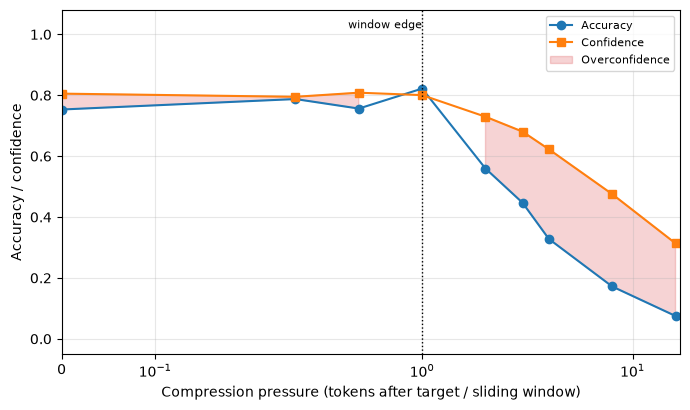

In [3]:
by_pressure = h3_calibration.by_pressure(df)
report.plot_confidence_gap(by_pressure, config.figure_path("h3_confidence_gap", MODE))
by_pressure[["pressure_windows", "memory_condition", "accuracy", "confidence",
             "gap", "gap_ci_low", "gap_ci_high", "ece", "brier", "cwr", "n"]].round(3)

## Reliability diagrams and the H1×H3 crossover

Two diagrams, one per memory condition. Points below the diagonal are overconfident.
Comparing them is the cleanest visual statement of H3: the exact-memory curve is the
model's baseline calibration, and any extra sag in the recurrent curve is what
compression caused.

The per-fact-type table asks whether the categories H1 finds most fragile are also the
ones the model is most overconfident about — the strongest version of the paper's story,
since it means the model cannot tell which of its memories it has lost.

,fact_type,accuracy,confidence,gap,ece,brier,cwr,n
0,multi-hop,0.318,0.606,0.289,0.289,0.246,0.573,384
1,numerical,0.365,0.605,0.240,0.240,0.237,0.511,384
2,contradictory,0.411,0.602,0.190,0.190,0.224,0.453,384
3,entity-attribute,0.419,0.600,0.180,0.180,0.216,0.448,384
4,temporal,0.490,0.606,0.116,0.116,0.213,0.399,384


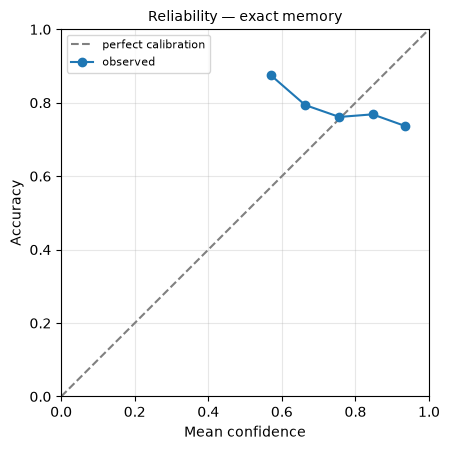

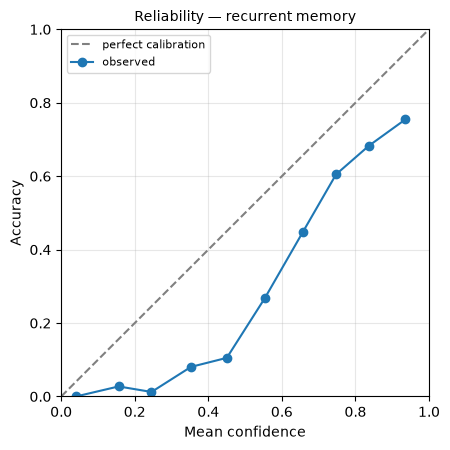

In [4]:
for condition in ["exact_memory", "recurrent_memory"]:
    if (df["memory_condition"] == condition).any():
        bins = h3_calibration.reliability(df, condition=condition)
        report.plot_reliability(
            bins,
            config.figure_path(f"h3_reliability_{condition}", MODE),
            title=f"Reliability — {condition.replace('_', ' ')}",
        )

h3_calibration.by_fact_type(df).round(3)

## H3 table

One row per memory condition. The claim is carried by the `gap` and `cwr` columns
growing from exact to recurrent memory, not by the absolute ECE.

In [5]:
cfg = config.experiment()["calibration"]

path = report.write_table(
    by_condition,
    name="h3_calibration",
    title="H3 — Calibration under compression",
    mode=MODE,
    synthetic=SYNTHETIC,
    notes=[
        f"ECE: Guo et al. 2017 (ICML), {cfg['ece_bins']} equal-width bins. Brier: Brier 1950.",
        f"CWR threshold = {cfg['cwr_threshold']} (provisional, open decision #5).",
        f"Confidence = {cfg['confidence']} (provisional, open decision #6).",
    ],
)
print("wrote", path.relative_to(ROOT), "\n")
print(report.gate_report(df).to_string(index=False))
by_condition.round(3)

wrote outputs/tables/h3_calibration_pilot.md 

                   gate          scope verdict                                                detail
  exact_memory_accuracy       deltanet    PASS                      79.6% inside the defensible band
  exact_memory_accuracy gated_deltanet    PASS                      72.5% inside the defensible band
  exact_memory_accuracy         mamba2    WARN            80.8% above the band, within the 85% bound
  exact_memory_accuracy    transformer    PASS                      73.3% inside the defensible band
     window_is_exceeded         design    PASS 1920/2880 trials past the 256-token window (max 4096)
       threshold_locked             H2 BLOCKED                          H2 threshold T is not locked
threshold_clears_window             H2    PASS                     T=768 tokens = 3.0 windows of 256
          min_cell_size            all    PASS                                all cells large enough
         matched_design            all    PA

,memory_condition,accuracy,confidence,gap,ece,brier,cwr,abstention_rate,n
0,exact_memory,0.766,0.803,0.037,0.072,0.191,0.234,0.0,960
1,recurrent_memory,0.401,0.604,0.203,0.203,0.227,0.477,0.0,1920
